# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [ ]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

In [ ]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [ ]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams # Import ngrams

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str, enable_bigrams: bool = False) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, lemmatize, and optionally generate bigrams."""
    # Lowercase and tokenize the text
    tokens = nltk.word_tokenize(text.lower())

    # Remove punctuation tokens
    tokens = [token for token in tokens if token not in string.punctuation]

    # Filter out stopwords
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize remaining tokens
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Optionally generate bigrams
    if enable_bigrams:
        bigrams = list(ngrams(lemmatized_tokens, 2))
        # Convert bigrams to string format 'word1_word2'
        bigram_tokens = [f"{w1}_{w2}" for w1, w2 in bigrams]
        lemmatized_tokens.extend(bigram_tokens)

    # Join back into a single cleaned string
    return ' '.join(lemmatized_tokens)

In [ ]:
# Test the preprocess_text function with a sample review
sample_review = raw_reviews[0]
cleaned_sample_review = preprocess_text(sample_review)

print(f"Original Review: {sample_review}")
print(f"Cleaned Review: {cleaned_sample_review}")

Original Review: At McDonald's the food was ok and the service was bad.
Cleaned Review: mcdonald 's food ok service bad


### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [ ]:
# Apply preprocess_text to every review and keep both raw and cleaned versions
cleaned_reviews = [preprocess_text(review, enable_bigrams=True) for review in raw_reviews]

if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")

RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad mcdonald_'s 's_food food_ok ok_service service_bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone would_recommend recommend_japanese japanese_restaurant restaurant_anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer loved_restaurant restaurant_traveled traveled_thailand thailand_last last_summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option menu_loving loving_wide wide_variety variety_option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant staff_friendly friendly_helpful helpful_google google_'s 's_employee employee_restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are deli

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [ ]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    doc = nlp(text)
    entities = []
    for ent in doc.ents:
        entities.append((ent.text, ent.label_))
    return entities

### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [ ]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    # Tokenize the text
    tokens = word_tokenize(text)
    # Call nltk.pos_tag on the tokens
    return pos_tag(tokens)

### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [ ]:
sample_texts = raw_reviews[:2]
sample_cleaned_texts = cleaned_reviews[:2]

print("NER on raw text")
for text in sample_texts:
    print(f"Raw: {text}")
    print(f"NER: {perform_ner(text)}\n")

print("NER on cleaned text")
for text in sample_cleaned_texts:
    print(f"Cleaned: {text}")
    print(f"NER: {perform_ner(text)}\n")

print("POS tags on raw text")
for text in sample_texts:
    print(f"Raw: {text}")
    print(f"POS: {perform_pos_tagging(text)}\n")

print("POS tags on cleaned text")
for text in sample_cleaned_texts:
    print(f"Cleaned: {text}")
    print(f"POS: {perform_pos_tagging(text)}\n")

NER on raw text
Raw: At McDonald's the food was ok and the service was bad.
NER: [('McDonald', 'ORG')]

Raw: I would not recommend this Japanese restaurant to anyone.
NER: [('Japanese', 'NORP')]

NER on cleaned text
Cleaned: mcdonald 's food ok service bad
NER: [("mcdonald 's food ok service", 'ORG')]

Cleaned: would recommend japanese restaurant anyone
NER: [('japanese', 'NORP')]

POS tags on raw text
Raw: At McDonald's the food was ok and the service was bad.
POS: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]

Raw: I would not recommend this Japanese restaurant to anyone.
POS: [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]

POS tags on cleaned text
Cleaned: mcdonald 's food ok service bad
POS: [('mcdonald', 

## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [ ]:
from gensim.models import Word2Vec

# Ensure cleaned_reviews is defined from Exercise 1
# Tokenize on whitespace after preprocessing
tokenized_reviews = [review.split() for review in cleaned_reviews]

# Train the Word2Vec model
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=1, sg=0)
w2v_model

### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [ ]:
# Print the vector size and vocabulary size of your model
print(f"Vector size: {w2v_model.vector_size}")
print(f"Vocabulary size: {len(w2v_model.wv)}")

Vector size: 100
Vocabulary size: 56


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

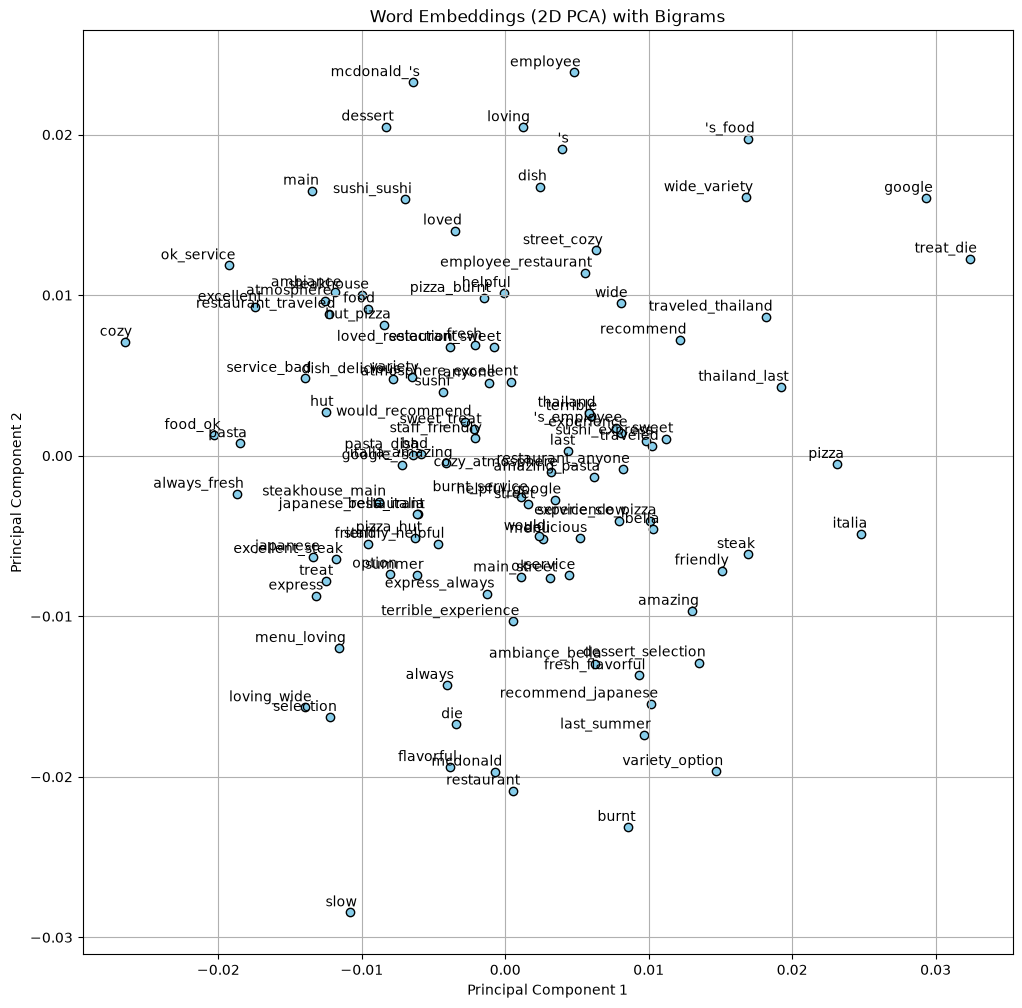

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_word_embeddings(model, words=None):
    if words is None:
        words = list(model.wv.index_to_key)

    vectors = [model.wv[word] for word in words if word in model.wv]
    labels = [word for word in words if word in model.wv]

    if not vectors:
        print("No words found in vocabulary to plot.")
        return

    # Reduce dimensionality to 2D using PCA
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(np.array(vectors))

    plt.figure(figsize=(12, 12))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='skyblue')

    for i, word in enumerate(labels):
        plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                     xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')

    plt.title('Word Embeddings (2D PCA) with Bigrams')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)
    plt.show()

# Call the plotting function using your trained model
plot_word_embeddings(w2v_model)

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.